# Valorant Player Interaction Analytics
This notebook serves as the comprehensive implementation of the Network Science project. We construct a player interaction network from professional Valorant matches and analyze its topology to extract insights and predict match outcomes.

**Deliverables Covered:**
1. **Deliverable 1**: Graph Construction
2. **Deliverable 2**: Network Analysis
3. **Deliverable 3**: Community Detection
4. **Deliverable 4**: Machine Learning Match Predictor

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
import pickle
import kagglehub

sns.set_theme(style="whitegrid")
os.makedirs('../data', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

## 0. Data Loading & Preprocessing
We'll start by downloading and cleaning the matches dataset.

In [3]:
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("qualidea1217/valorant-pro-matches-since-april-2021")
csv_path = os.path.join(path, "data-since-april-2021.csv")

print(f"Loading data from {csv_path}...")
df = pd.read_csv(csv_path, encoding='latin-1', low_memory=False)

print("Cleaning and engineering features...")
df['match_id'] = (df['match-datetime'].astype(str) + '_' + 
                  df['team1'].astype(str) + '_' + 
                  df['team2'].astype(str) + '_' + 
                  df['map'].astype(str))

df = df.dropna(subset=['player-name', 'player-team', 'team1-score', 'team2-score'])

def determine_win(row):
    try:
        t1_score = int(row['team1-score'])
        t2_score = int(row['team2-score'])
        if row['player-team'] == row['team1']:
            return 1 if t1_score > t2_score else 0
        elif row['player-team'] == row['team2']:
            return 1 if t2_score > t1_score else 0
        return 0
    except:
        return 0

df['won'] = df.apply(determine_win, axis=1)

cols = ['match_id', 'player-name', 'player-team', 'team1', 'team2', 
        'k', 'd', 'a', 'won', 'rating', 'acs']
clean_df = df[cols].copy()

match_counts = clean_df.groupby('match_id')['player-name'].count()
valid_matches = match_counts[match_counts >= 10].index
clean_df = clean_df[clean_df['match_id'].isin(valid_matches)]

clean_df['player-name'] = clean_df['player-name'].str.lower().str.strip()
print(f"Dataset ready with {len(clean_df)} valid player-match records.")
clean_df.head(3)

Loading data from C:\Users\user\.cache\kagglehub\datasets\qualidea1217\valorant-pro-matches-since-april-2021\versions\3\data-since-april-2021.csv...
Cleaning and engineering features...
Dataset ready with 249710 valid player-match records.


,match_id,player-name,player-team,team1,team2,k,d,a,won,rating,acs
0,2023/4/16 10:00_Impulse GW_EGN Esports_Haven,holym0ly,Impulse GW,Impulse GW,EGN Esports,20.0,11.0,1.0,1,1.32,267.0
1,2023/4/16 10:00_Impulse GW_EGN Esports_Haven,dolfo,Impulse GW,Impulse GW,EGN Esports,16.0,13.0,14.0,1,1.22,239.0
2,2023/4/16 10:00_Impulse GW_EGN Esports_Haven,zepiczz,Impulse GW,Impulse GW,EGN Esports,12.0,10.0,8.0,1,1.13,202.0


## Deliverable 1: Graph Construction
**Goal**: Build a network where nodes are players and edges denote co-participation in a match. Edge weight increases the more matches two players share.

In [4]:
G = nx.Graph()

print("Calculating player attributes...")
clean_df['k'] = pd.to_numeric(clean_df['k'], errors='coerce').fillna(0)
player_stats = clean_df.groupby('player-name').agg(
    matches_played=('match_id', 'count'),
    avg_kills=('k', 'mean'),
    win_rate=('won', 'mean')
).reset_index()

for _, row in player_stats.iterrows():
    G.add_node(row['player-name'], matches_played=row['matches_played'], avg_kills=row['avg_kills'], win_rate=row['win_rate'])

edges = {}
grouped = clean_df.groupby('match_id')

print("Adding edges (this may take a minute depending on hardware)...")
match_count = 0
for match_id, match_data in grouped:
    match_count += 1
    players_in_match = match_data[['player-name', 'player-team']].to_dict('records')
    
    for p1, p2 in combinations(players_in_match, 2):
        name1, name2 = p1['player-name'], p2['player-name']
        if name1 > name2:
            name1, name2 = name2, name1
            
        edge_key = (name1, name2)
        if edge_key not in edges:
            edges[edge_key] = {'weight': 0}
            
        edges[edge_key]['weight'] += 1

ebunch = [(u, v, attr) for (u, v), attr in edges.items()]
G.add_edges_from(ebunch)
    
print(f"Graph built successfully! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Calculating player attributes...
Adding edges (this may take a minute depending on hardware)...
Graph built successfully! Nodes: 8793 | Edges: 236225


## Deliverable 2 & 3: Network Analysis & Community Detection
**Goal**: Compute structural properties of the graph (Deliverable 2) and extract communities using Louvain (Deliverable 3).

Computing PageRank...
Largest Connected Component has 8710 nodes.
Computing Degree Centrality...
Detecting Communities via Louvain Method...
Metrics computed successfully!


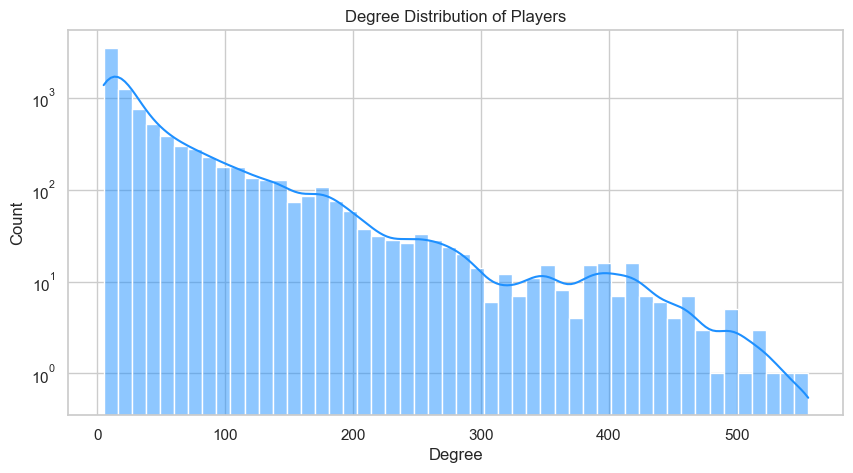

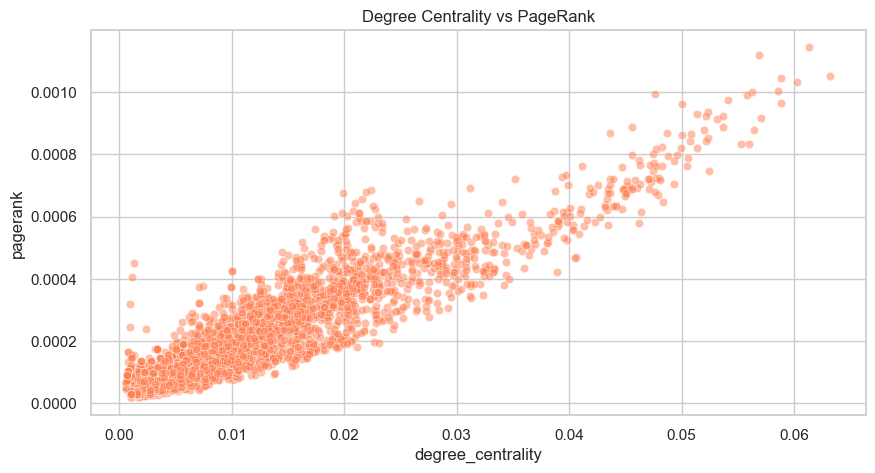

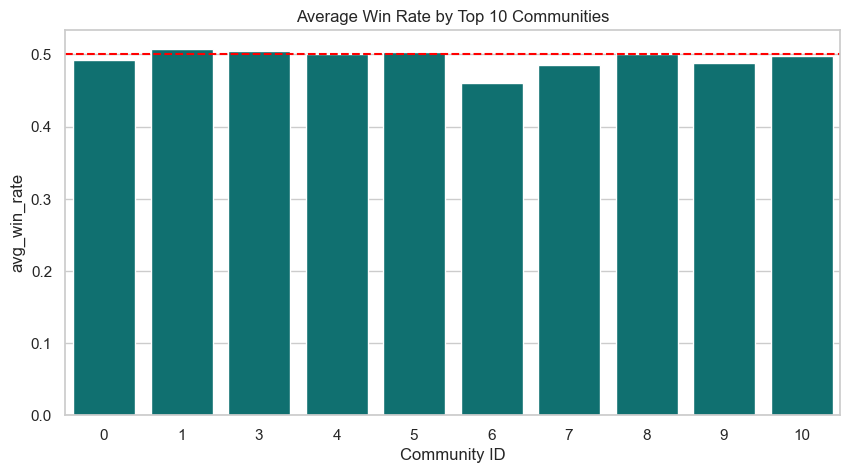

In [7]:
degrees = dict(G.degree())
print("Computing PageRank...")
pagerank = nx.pagerank(G, weight='weight')

largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc).copy()
print(f"Largest Connected Component has {G_cc.number_of_nodes()} nodes.")

print("Computing Degree Centrality...")
degree_cent = nx.degree_centrality(G)

print("Detecting Communities via Louvain Method...")
partition = community_louvain.best_partition(G, weight='weight')

metrics_list = []
for node in G.nodes():
    node_attr = G.nodes[node]
    metrics_list.append({
        'player': node,
        'degree': degrees.get(node, 0),
        'pagerank': pagerank.get(node, 0),
        'degree_centrality': degree_cent.get(node, 0),
        'community': partition.get(node, -1),
        'matches_played': node_attr.get('matches_played', 0),
        'avg_kills': node_attr.get('avg_kills', 0),
        'win_rate': node_attr.get('win_rate', 0)
    })
    
df_metrics = pd.DataFrame(metrics_list)
print("Metrics computed successfully!")

# Visualization Sub-Block
plt.figure(figsize=(10, 5))
sns.histplot(df_metrics['degree'], bins=50, kde=True, color='dodgerblue')
plt.title('Degree Distribution of Players')
plt.yscale('log')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.savefig('../results/plots/degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x='degree_centrality', y='pagerank', data=df_metrics, alpha=0.5, color='coral')
plt.title('Degree Centrality vs PageRank')
plt.savefig('../results/plots/centrality_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Community Aggregates
df_metrics['total_wins'] = df_metrics['win_rate'] * df_metrics['matches_played']
comm_stats = df_metrics.groupby('community').agg(
    size=('player', 'count'),
    total_wins=('total_wins', 'sum'),
    total_matches=('matches_played', 'sum')
)
comm_stats['avg_win_rate'] = comm_stats['total_wins'] / comm_stats['total_matches']
comm_stats = comm_stats.sort_values('size', ascending=False)

comm_stats_top = comm_stats.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=comm_stats_top.index, y='avg_win_rate', data=comm_stats_top, color='teal')
plt.title('Average Win Rate by Top 10 Communities')
plt.axhline(0.5, color='red', linestyle='--')
plt.xlabel('Community ID')
plt.savefig('../results/plots/community_win_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## Deliverable 4: Machine Learning Predictor
**Goal**: Given a match, predict the winning team strictly by comparing the centralities and degrees of the teams. We merge the newly computed graph metrics into our match dataframe, engineer team-differentials, and fit a Random Forest model.

Engineering Match DataFrame...
Generated 24922 match instances for ML.
Random Forest Predictor Accuracy based strictly on network structure: 0.6622

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.66      0.65      2410
           1       0.67      0.67      0.67      2575

    accuracy                           0.66      4985
   macro avg       0.66      0.66      0.66      4985
weighted avg       0.66      0.66      0.66      4985



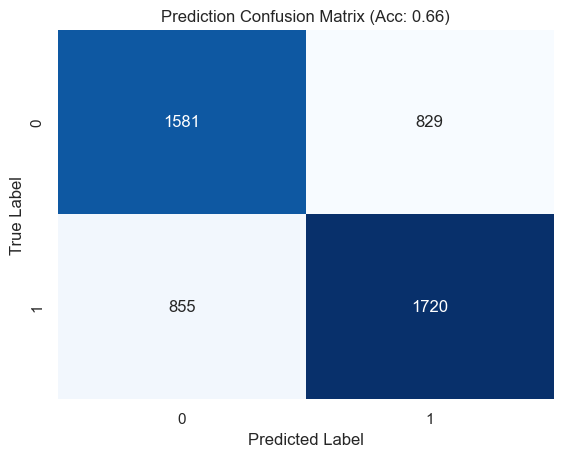

In [6]:
print("Engineering Match DataFrame...")
merged = clean_df.merge(df_metrics[['player', 'degree', 'pagerank']], left_on='player-name', right_on='player', how='left')

team_stats = merged.groupby(['match_id', 'player-team']).agg(
    avg_degree=('degree', 'mean'),
    avg_pagerank=('pagerank', 'mean'),
    won=('won', 'max')
).reset_index()

match_features = []
grouped_match = team_stats.groupby('match_id')

for match_id, group in grouped_match:
    if len(group) == 2:
        t1, t2 = group.iloc[0], group.iloc[1]
        match_features.append({
            'diff_degree': t1['avg_degree'] - t2['avg_degree'],
            'diff_pagerank': t1['avg_pagerank'] - t2['avg_pagerank'],
            'target': t1['won']
        })
        
ml_df = pd.DataFrame(match_features).dropna()
print(f"Generated {len(ml_df)} match instances for ML.")

X = ml_df[['diff_degree', 'diff_pagerank']]
y = ml_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Predictor Accuracy based strictly on network structure: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Prediction Confusion Matrix (Acc: {acc:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../results/plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()